# Inward remittance volumes by country, 1980-2019

*'The World Bank provides annual estimates of remittances flows globally (and bilaterally), based on national balance of payment statistics produced by central Banks and compiled by the IMF.'* 
[Commentary from Migration Data Portal](https://migrationdataportal.org/themes/remittances#data-sources). 

There are multiple methodological challenges in collecting the data:
* It could be under-reported as payments to UN staff and other multinationals can be counted as remittances; and remittance criteria is based on residence rather than migratory status 
* It could be over-reported as there have been multiple changes in measurement from 1980-2019, with some arguing that 80% of the increase from 1990 is due to measurement changes; and also not all payment channels are included, as it measurement only uses bank transfers and exclude money transfer operators and informal payment channels. 

Source data: [World Bank Data Catalogue](https://www.knomad.org/data/remittances), accessed 14th Feb 2021

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import ExcelWriter
from pandas import ExcelFile

In [9]:
df = pd.read_excel('/Users/bendixon/Documents/GitHub/python-sandbox/Inward_Remittance_Flows.xlsx')
df = df.transpose()
df = df.iloc[0:41,0:216]
countries = df.iloc[0,:] 
new_header = df.iloc[0] # take the first row for the header
df = df[1:] # take the data less the header row
df.columns = new_header # set the header row as the df header
df = df.rename_axis("Year", axis="columns") # Renaming the index column as year (it was prev remittance vol)
df.head()

Year,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Aruba,...,Vanuatu,"Venezuela, RB",Vietnam,Virgin Islands (U.S.),West Bank and Gaza,"Yemen, Rep.",Zambia,Zimbabwe,Low-and Middle-Income Countries,World
1980,NaN,NaN,406,NaN,NaN,NaN,NaN,56,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.8916,17624.2,35813.9
1981,NaN,NaN,447,NaN,NaN,NaN,NaN,42,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.2946,17847.6,34887.2
1982,NaN,NaN,507,NaN,NaN,NaN,NaN,28,NaN,NaN,...,9.35478,NaN,NaN,NaN,NaN,NaN,NaN,32.8953,19286,36041.3
1983,NaN,NaN,392,NaN,NaN,NaN,NaN,28,NaN,NaN,...,7.14518,NaN,NaN,NaN,NaN,NaN,NaN,19.5562,20848,36578.4
1984,NaN,NaN,329,NaN,NaN,NaN,NaN,32,NaN,NaN,...,8.46801,NaN,NaN,NaN,NaN,NaN,NaN,3.80629,20161.1,35361.1


In [10]:
countries

0                          Afghanistan
1                              Albania
2                              Algeria
3                       American Samoa
4                              Andorra
                    ...               
211                        Yemen, Rep.
212                             Zambia
213                           Zimbabwe
214    Low-and Middle-Income Countries
215                              World
Name: Migrant remittance inflows (US$ million), Length: 216, dtype: object

In [11]:
listc = []
for i in countries:
    listc.append(i)
print(listc)

['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas, The', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands', 'Central African Republic', 'Chad', 'Channel Islands', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Croatia', 'Cuba', 'Curacao', 'Cyprus', 'Czech Republic', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt, Arab Rep.', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Faeroe Islands', 'Fiji', 'Finland', 'France', 'French Polynesia', 'Gabon', 'Gambia, The', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Greenl

In [52]:
non_e = ['Ghana', 'Nigeria', 'Senegal']


eastern = ['Djibouti', 'Eritrea', 'Ethiopia', 'Somalia', 'Sudan', 'South Sudan', 'Madagascar', 'Mauritius',
 'Comoros', 'Seychelles', 'Uganda', 'Rwanda', 'Burundi', 'Kenya', 'Tanzania', 'Mozambique', 'Malawi', 
 'Zambia', 'Zimbabwe']

In [22]:
j = 0
for i in eastern: 
    print(listc.index(i))
    j = j + 1
print("Total :",j)

53
60
63
173
182
175
116
124
42
166
199
159
30
99
188
132
117
212
213
Total : 19


In [26]:
len(eastern)

19

In [21]:
for i in non_e:
    print(listc.index(i))

73
141
164


In [35]:
new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Empty DataFrame

In [54]:
# Nailed it!
df_e = pd.DataFrame()
for i in eastern:
    add = df[[i]].copy()
    df_e = pd.concat([df_e, add], axis=1)
df_e.head()

Year,Djibouti,Eritrea,Ethiopia,Somalia,Sudan,South Sudan,Madagascar,Mauritius,Comoros,Seychelles,Uganda,Rwanda,Burundi,Kenya,Tanzania,Mozambique,Malawi,Zambia,Zimbabwe
1980,NaN,NaN,12.2222,NaN,262.6,NaN,0.378647,NaN,1.61872,NaN,NaN,3.38121,NaN,12.9377,NaN,53.4,NaN,NaN,16.8916
1981,NaN,NaN,10.4831,NaN,383.672,NaN,0.220807,NaN,1.2218,NaN,NaN,3.90086,NaN,7.40536,NaN,64.5,NaN,NaN,28.2946
1982,NaN,NaN,10.1932,NaN,133.221,NaN,0.114372,NaN,2.3676,NaN,NaN,7.17817,NaN,7.04978,NaN,63.5,NaN,NaN,32.8953
1983,NaN,NaN,11.0145,NaN,275,NaN,0.116158,NaN,1.83697,NaN,NaN,3.43414,NaN,5.70934,NaN,75.2,NaN,NaN,19.5562
1984,NaN,NaN,11.4976,NaN,285,NaN,5.63607,NaN,2.13982,NaN,NaN,2.94315,NaN,5.82772,NaN,57,NaN,NaN,3.80629


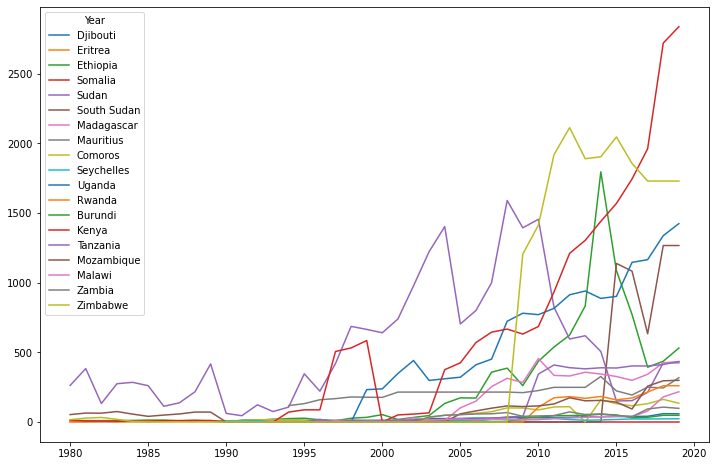

In [55]:
df_e.plot(figsize=(12,8))

In [56]:
# Nailed it!
df_ne = pd.DataFrame()
for i in non_e:
    add = df[[i]].copy()
    df_ne = pd.concat([df_ne, add], axis=1)
df_ne.head()

Year,Ghana,Nigeria,Senegal
1980,0.9,21.9466,77.0543
1981,1.4,16.1889,68.1923
1982,1.5,17.8184,66.3104
1983,0.5,13.8043,58.9662
1984,4.7,11.7413,53.7582


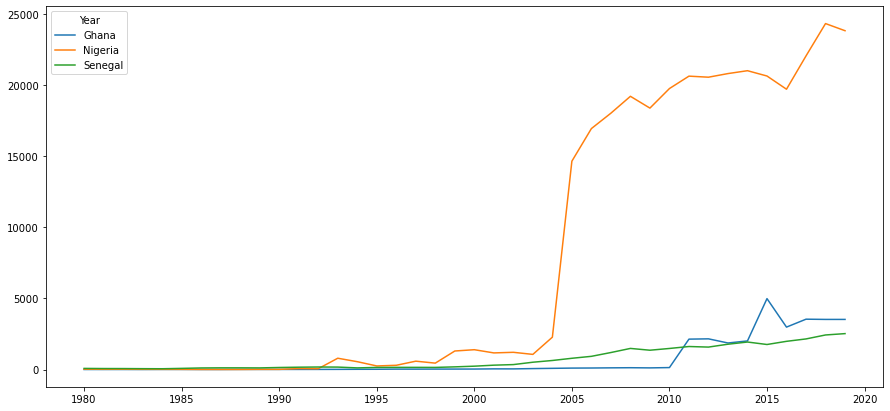

In [58]:
df_ne.plot(figsize=(15,7))

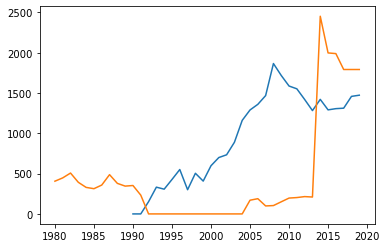

In [16]:
current = ['Albania','Algeria']
for i in current:
    df[i].plot()

In [17]:
df.head()

Year,Afghanistan,Albania,Algeria,American Samoa,Andorra,Angola,Antigua and Barbuda,Argentina,Armenia,Aruba,...,Vanuatu,"Venezuela, RB",Vietnam,Virgin Islands (U.S.),West Bank and Gaza,"Yemen, Rep.",Zambia,Zimbabwe,Low-and Middle-Income Countries,World
1980,NaN,NaN,406,NaN,NaN,NaN,NaN,56,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.8916,17624.2,35813.9
1981,NaN,NaN,447,NaN,NaN,NaN,NaN,42,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.2946,17847.6,34887.2
1982,NaN,NaN,507,NaN,NaN,NaN,NaN,28,NaN,NaN,...,9.35478,NaN,NaN,NaN,NaN,NaN,NaN,32.8953,19286,36041.3
1983,NaN,NaN,392,NaN,NaN,NaN,NaN,28,NaN,NaN,...,7.14518,NaN,NaN,NaN,NaN,NaN,NaN,19.5562,20848,36578.4
1984,NaN,NaN,329,NaN,NaN,NaN,NaN,32,NaN,NaN,...,8.46801,NaN,NaN,NaN,NaN,NaN,NaN,3.80629,20161.1,35361.1


In [18]:
df.shape

(40, 216)

In [19]:
dff = dff.rename(columns={"Migrant remittance inflows (US$ million)": "Country"})

NameError: name 'dff' is not defined

In [ ]:
dff[1980] = dff[1980].astype(float)

In [ ]:
# Plotting the trend for Burundi
dff.iloc[30,1:].astype(float).plot()